In [1]:
import os
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

In [5]:
from datetime import datetime

In [2]:
from workflow.pipeline import lineage, culture

c:\Users\Organoid PC\anaconda3\envs\utah_organoids\lib\site-packages\datajoint\plugin.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
[2026-03-05 11:53:43,372][INFO]: DataJoint 0.14.4 connected to judewerth@db.datajoint.com:3306


Module stfio is not installed. Make sure .abf files are converted to .pkl in Python 2.


![Screenshot 2026-03-05 113557.png](<attachment:Screenshot 2026-03-05 113557.png>)
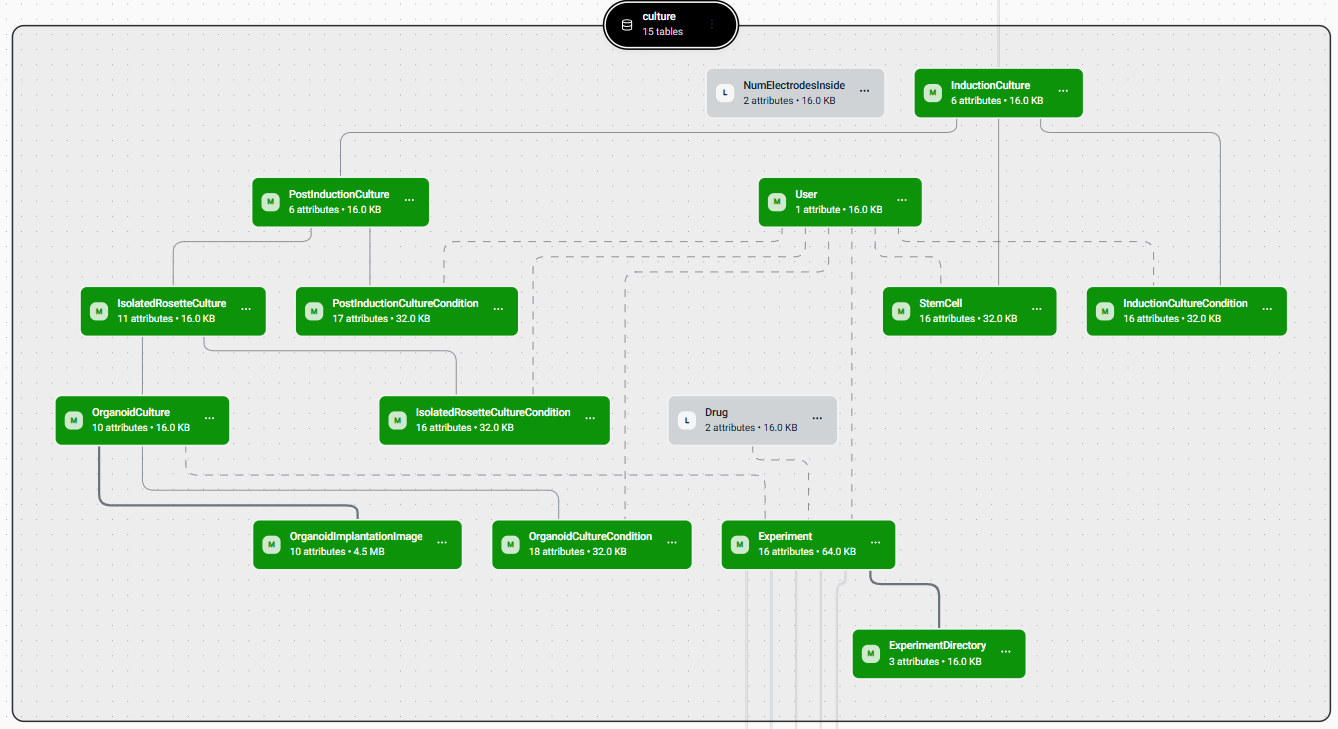

In [19]:
# Insert stem cell lineages used
esc_lineage = {
    "lineage_id": "line1_JW",
    "family": "ESC",
    "line": "H9",
    "passage": 53,
    "frozen_date": datetime(2022, 8, 3),
    "storage_position": 1,
    "stand": 1,
    "rack": 1,
    "box_position": 1,
    "lineage_note": "H9 ESC line used in organoids O09-O20"
}

ipsc_if3_lineage = {
    "lineage_id": "line2_JW",
    "family": "iPSC",
    "line": "IF3",
    "passage": 21,
    "frozen_date": datetime(2023, 10, 10),
    "storage_position": 1,
    "stand": 1,
    "rack": 1,
    "box_position": 1,
    "lineage_note": "IF3 iPSC line used in organoids O21-O24"
}

ipsc_f2m9_lineage = {
    "lineage_id": "line3_JW",
    "family": "iPSC",
    "line": "F2M9",
    "passage": 35,
    "frozen_date": datetime(2023, 10, 10),
    "storage_position": 1,
    "stand": 1,
    "rack": 1,
    "box_position": 1,
    "lineage_note": "F2M9 iPSC line used in organoids O25-O32"
}

lineage_list = [esc_lineage, ipsc_if3_lineage, ipsc_f2m9_lineage]

In [23]:
lineage.Lineage.insert(lineage_list, skip_duplicates=True)
lineage_keys = (lineage.Lineage & lineage_list).fetch("KEY")

lineage.Lineage & lineage_keys

lineage_id de-identified code (e.g. hmau001),family,line,passage,frozen_date,storage_position,stand,rack,box_position,lineage_note
line1_JW,ESC,H9,53,2022-08-03,1,1,1,1,H9 ESC line used in organoids O09-O20
line2_JW,iPSC,IF3,21,2023-10-10,1,1,1,1,IF3 iPSC line used in organoids O21-O24
line3_JW,iPSC,F2M9,35,2023-10-10,1,1,1,1,F2M9 iPSC line used in organoids O25-O32


In [30]:
esc_induction = {
    **(lineage.Lineage & esc_lineage).fetch1("KEY"),
    "induction_culture_date": datetime(2022, 9, 6),
    "induction_culture_plate": 6,
    "induction_culture_wells": 1,
    "culture_plate_type": "traditional plate",
    "induction_culture_note": "Induction culture for H9 ESC line"
}

ipsc_if3_induction = {
    **(lineage.Lineage & ipsc_if3_lineage).fetch1("KEY"),
    "induction_culture_date": datetime(2023, 12, 4),
    "induction_culture_plate": 6,
    "induction_culture_wells": 1,
    "culture_plate_type": "traditional plate",
    "induction_culture_note": "Induction culture for IF3 iPSC line. In same batch as F2M9 induction culture"
}

ipsc_f2m9_induction = {
    **(lineage.Lineage & ipsc_f2m9_lineage).fetch1("KEY"),
    "induction_culture_date": datetime(2023, 12, 4),
    "induction_culture_plate": 6,
    "induction_culture_wells": 2,
    "culture_plate_type": "traditional plate",
    "induction_culture_note": "Induction culture for F2M9 iPSC line. In same batch as IF3 induction culture"
}

induction_culture_list = [esc_induction, ipsc_if3_induction, ipsc_f2m9_induction]

In [31]:
culture.InductionCulture.insert(induction_culture_list, skip_duplicates=True)
induction_culture_keys = (culture.InductionCulture & induction_culture_list).fetch("KEY")

culture.InductionCulture & induction_culture_keys

lineage_id de-identified code (e.g. hmau001),induction_culture_date,induction_culture_plate,induction_culture_wells Ranges of wells occupied (e.g. 1-3),culture_plate_type,induction_culture_note
line1_JW,2022-09-06,6,1,traditional plate,Induction culture for H9 ESC line
line2_JW,2023-12-04,6,1,traditional plate,Induction culture for IF3 iPSC line. In same batch as F2M9 induction culture
line3_JW,2023-12-04,6,2,traditional plate,Induction culture for F2M9 iPSC line. In same batch as IF3 induction culture


In [38]:
esc_post_induction = {
    **(culture.InductionCulture & esc_induction).fetch1("KEY"),
    "post_induction_culture_date": datetime(2022, 9, 9),
    "post_induction_culture_plate": 10,
    "post_induction_culture_wells": "dish",
    }

ipsc_if3_post_induction = {
    **(culture.InductionCulture & ipsc_if3_induction).fetch1("KEY"),
    "post_induction_culture_date": datetime(2023, 12, 11),
    "post_induction_culture_plate": 10,
    "post_induction_culture_wells": "dish",
    }

ipsc_f2m9_post_induction = {
    **(culture.InductionCulture & ipsc_f2m9_induction).fetch1("KEY"),
    "post_induction_culture_date": datetime(2023, 12, 11),
    "post_induction_culture_plate": 10,
    "post_induction_culture_wells": "dish",
    }

post_induction_culture_list = [esc_post_induction, ipsc_if3_post_induction, ipsc_f2m9_post_induction]

In [39]:
culture.PostInductionCulture.insert(post_induction_culture_list, skip_duplicates=True)
post_induction_culture_keys = (culture.PostInductionCulture & post_induction_culture_list).fetch("KEY")

culture.PostInductionCulture & post_induction_culture_keys

lineage_id de-identified code (e.g. hmau001),induction_culture_date,induction_culture_plate,post_induction_culture_date,post_induction_culture_plate,post_induction_culture_wells Ranges of wells occupied (e.g. 1-3)
line1_JW,2022-09-06,6,2022-09-09,10,dish
line2_JW,2023-12-04,6,2023-12-11,10,dish
line3_JW,2023-12-04,6,2023-12-11,10,dish


In [44]:
esc_isolated_rosette = {
    **(culture.PostInductionCulture & esc_post_induction).fetch1("KEY"),
    "isolated_rosette_culture_date": datetime(2022, 9, 19),
    "isolated_rosette_culture_plate": 96,
    "isolated_rosette_culture_wells": "1-12",
    "isolated_rosette_culture_note": "Isolated rossettes for O09-O12: wells 1-4, O13-O16: wells 5-8, O17-O20: wells 9-12"
}

ipsc_if3_isolated_rosette = {
    **(culture.PostInductionCulture & ipsc_if3_post_induction).fetch1("KEY"),
    "isolated_rosette_culture_date": datetime(2023, 12, 19),
    "isolated_rosette_culture_plate": 96,
    "isolated_rosette_culture_wells": "1-4",
    "isolated_rosette_culture_note": "Isolated rossettes for O21-O24: wells 1-4"
}

ipsc_f2m9_isolated_rosette = {
    **(culture.PostInductionCulture & ipsc_f2m9_post_induction).fetch1("KEY"),
    "isolated_rosette_culture_date": datetime(2023, 12, 19),
    "isolated_rosette_culture_plate": 96,
    "isolated_rosette_culture_wells": "5-12",
    "isolated_rosette_culture_note": "Isolated rossettes for O25-O28: wells 5-8, O29-O32: wells 9-12"
}

isolated_rosette_culture_list = [
    esc_isolated_rosette,
    ipsc_if3_isolated_rosette,
    ipsc_f2m9_isolated_rosette
]

In [47]:
culture.IsolatedRosetteCulture.insert(isolated_rosette_culture_list, skip_duplicates=True)
isolated_rosette_culture_keys = (culture.IsolatedRosetteCulture & isolated_rosette_culture_list).fetch("KEY")

culture.IsolatedRosetteCulture & isolated_rosette_culture_keys

[2026-03-05 13:52:41,386][WARNING]: Reconnecting to MySQL server.


lineage_id de-identified code (e.g. hmau001),induction_culture_date,induction_culture_plate,post_induction_culture_date,post_induction_culture_plate,isolated_rosette_culture_date Date for isolating the rosette,isolated_rosette_culture_plate,isolated_rosette_culture_wells Ranges of wells occupied (e.g. A1-B2),size Units of millimeters,number_of_lumen,isolated_rosette_culture_note
line1_JW,2022-09-06,6,2022-09-09,10,2022-09-19,96,1-12,None,None,"Isolated rossettes for O09-O12: wells 1-4, O13-O16: wells 5-8, O17-O20: wells 9-12"
line2_JW,2023-12-04,6,2023-12-11,10,2023-12-19,96,1-4,None,None,Isolated rossettes for O21-O24: wells 1-4
line3_JW,2023-12-04,6,2023-12-11,10,2023-12-19,96,5-12,None,None,"Isolated rossettes for O25-O28: wells 5-8, O29-O32: wells 9-12"


In [48]:
esc_organoid_culture_plates = [9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
esc_organoid_cultures = [
    {
        **(culture.IsolatedRosetteCulture & esc_isolated_rosette).fetch1("KEY"),
        "organoid_culture_date": datetime(2022, 10, 10),
        "organoid_culture_plate": organoid_culture_plate,
        "isolated_rosette_culture_wells": f"{organoid_culture_plate - 8}"
    } 
    for organoid_culture_plate in esc_organoid_culture_plates
    ]

ipsc_if3_organoid_culture_plates = [21, 22, 23, 24]
ispc_if3_organoid_cultures = [
    {
        **(culture.IsolatedRosetteCulture & ipsc_if3_isolated_rosette).fetch1("KEY"),
        "organoid_culture_date": datetime(2024, 1, 13),
        "organoid_culture_plate": organoid_culture_plate,
        "isolated_rosette_culture_wells": f"{organoid_culture_plate - 20}"
    } 
    for organoid_culture_plate in ipsc_if3_organoid_culture_plates
    ]

ipsc_f2m9_organoid_culture_plates = [25, 26, 27, 28, 29, 30, 31, 32]
ispc_f2m9_organoid_cultures = [
    {
        **(culture.IsolatedRosetteCulture & ipsc_f2m9_isolated_rosette).fetch1("KEY"),
        "organoid_culture_date": datetime(2024, 1, 13),
        "organoid_culture_plate": organoid_culture_plate,
        "isolated_rosette_culture_wells": f"{organoid_culture_plate - 20}"
    } 
    for organoid_culture_plate in ipsc_f2m9_organoid_culture_plates
    ]

organoid_culture_list = esc_organoid_cultures + ispc_if3_organoid_cultures + ispc_f2m9_organoid_cultures

[2026-03-05 13:59:57,691][WARNING]: Reconnecting to MySQL server.


In [49]:
culture.OrganoidCulture.insert(organoid_culture_list, skip_duplicates=True)
organoid_culture_keys = (culture.OrganoidCulture & organoid_culture_list).fetch("KEY")

culture.OrganoidCulture & organoid_culture_keys

lineage_id de-identified code (e.g. hmau001),induction_culture_date,induction_culture_plate,post_induction_culture_date,post_induction_culture_plate,isolated_rosette_culture_date Date for isolating the rosette,isolated_rosette_culture_plate,organoid_culture_date,organoid_culture_plate,isolated_rosette_culture_wells Wells from the 96-well plate used to embed organoids
line1_JW,2022-09-06,6,2022-09-09,10,2022-09-19,96,2022-10-10,9,1
line1_JW,2022-09-06,6,2022-09-09,10,2022-09-19,96,2022-10-10,10,2
line1_JW,2022-09-06,6,2022-09-09,10,2022-09-19,96,2022-10-10,11,3
line1_JW,2022-09-06,6,2022-09-09,10,2022-09-19,96,2022-10-10,12,4
line1_JW,2022-09-06,6,2022-09-09,10,2022-09-19,96,2022-10-10,13,5
line1_JW,2022-09-06,6,2022-09-09,10,2022-09-19,96,2022-10-10,14,6
line1_JW,2022-09-06,6,2022-09-09,10,2022-09-19,96,2022-10-10,15,7
line1_JW,2022-09-06,6,2022-09-09,10,2022-09-19,96,2022-10-10,16,8
line1_JW,2022-09-06,6,2022-09-09,10,2022-09-19,96,2022-10-10,17,9
line1_JW,2022-09-06,6,2022-09-09,10,2022-09-19,96,2022-10-10,18,10


In [55]:
file_names = {
    9: "O9-A-32.tif",
    10: "O10-B-16.tif",
    11: "O11-C-20.tif",
    12: "O12-D-14.tif",
    13: "O13-A-25.tif",
    14: "O14-B-13.tif",
    15: "O15-C-11.tif",
    16: "O16-D-11.tif",
    17: "O17-GBM11-A-22.tif",
    18: "O18-GBM11-B-19.tif",
    19: "O19-GBM20-C-20.tif",
    20: "O20-GBM20-D-17.tif",
    21: "O21-A-18.tif",
    22: "O22-B-21.tif",
    23: "O23-C-22.tif",
    24: "O24-D-23.tif",
    25: "O25-GBM-A-20.jpg",
    26: "O26-GBM-B-32.jpg",
    27: "O27-GBM-C-26.jpg",
    28: "O28-GBM-D-24.jpg",
    29: "O29-A-22.HEIC",
    30: "O30-B-?.HEIC",
    31: "O31-C-?.HEIC",
    32: "O32-D-?.HEIC"
}

In [61]:
organoid_implantation_image_keys = []
for organoid_culture_plate, file_name in file_names.items():

    organoid_culture_key = (culture.OrganoidCulture & f"organoid_culture_plate='{organoid_culture_plate}'").fetch1("KEY")

    organoid_implantation_image_key = {
        **organoid_culture_key,
        "organoid_implantation_image": file_name
    }
    organoid_implantation_image_keys.append(organoid_implantation_image_key)

    culture.OrganoidImplantationImage.insert1(organoid_implantation_image_key, skip_duplicates=True)

culture.OrganoidImplantationImage & organoid_implantation_image_keys

FileNotFoundError: [Errno 2] No such file or directory: 'O9-A-32.tif'

In [59]:
organoid_culture_key

[{'lineage_id': 'line1_JW',
  'induction_culture_date': datetime.date(2022, 9, 6),
  'induction_culture_plate': 6,
  'post_induction_culture_date': datetime.date(2022, 9, 9),
  'post_induction_culture_plate': 10,
  'isolated_rosette_culture_date': datetime.date(2022, 9, 19),
  'isolated_rosette_culture_plate': 96,
  'organoid_culture_date': datetime.date(2022, 10, 10),
  'organoid_culture_plate': 9}]

In [58]:
culture.OrganoidImplantationImage()

lineage_id de-identified code (e.g. hmau001),induction_culture_date,induction_culture_plate,post_induction_culture_date,post_induction_culture_plate,isolated_rosette_culture_date Date for isolating the rosette,isolated_rosette_culture_plate,organoid_culture_date,organoid_culture_plate,organoid_implantation_image Organoid implantation image (TIF file)
hmau001,2023-10-12,6,2023-10-20,6,2023-10-12,1,2023-10-12,1,=BLOB=
